<h1><center>PheScape Tutorial</center></h1>


### Outline
Tutorial 1: Alzheimer dataset<br>
Tutorial 2: Hepatocellular carcinoma dataset<br>
Tutorial 3: Oral squamous cell carcinoma dataset<br>
Tutorial 4: Hepatocellular carcinoma dataset<br>

### Tutorial 1: Alzheimer dataset
Here, we reapply PheScape onto the AD1 slice of human Middle temporal gyrus (MTG) to demonstrates the identification of lesion location on 10x Visium data.
The spatial transcriptomics data for Alzheimer's disease are available from the Gene Expression Omnibus (GEO) under accession code GSE220442.<br>
The single-cell RNA-seq data can be accessed through the Allen Brain Atlas data portal (http://portal.brain-map.org/), and RNA-seq data from this study are publicly available at http://celltypes.brain-map.org/.<br>
The bulk RNA-seq data are available from GEO under accession code GSE39420<br>

1. Import python modules

In [1]:
import scanpy as sc

  2. Read in data

In [2]:
adata1 = sc.read_h5ad('AD_2-3.h5ad')
adata2 = sc.read_h5ad('sc_ad.h5ad')
adata3 = sc.read_h5ad('bulk_ad.h5ad')
adata1.var_names_make_unique()
adata2.var_names_make_unique()
adata3.var_names_make_unique()

E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  3. Load PheScape model

In [3]:
from model import phescape
myphescape_ad = phescape(data1=adata1,
                      data2=adata2,
                      data3=adata3,
                      sample='ad_1',
)
myphescape_ad.model_init()

Starting initializing the model...
Initialization completed


  4. Load data

In [4]:
adata1_new0, adata2_new, adata1_new1, adata3_new = myphescape_ad.load_data()

Starting loading data...


E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


Data loaded


  5. Calculate the coefficient of cell type deconvolution

In [5]:
S_ST_CL = myphescape_ad.cal_corr1(adata1_new0, adata2_new)

Calculate mapping from scRNA to ST


100%|██████████| 1000/1000 [08:09<00:00,  2.04it/s, loss: 2.819e+04]


GPU memory peak value for per slice: 2.90 GB
Run time for per slice: 8.16 分钟


  6. Visualization of cell type deconvolution<br>

Starting plotting...


E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


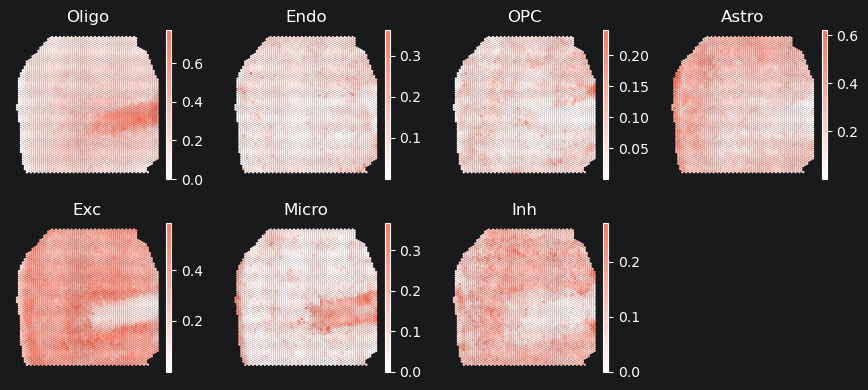

In [6]:
myphescape_ad.decplot(S_ST_CL)

  7. Calculate the coefficient of phenotypic mapping

In [7]:
S2 = myphescape_ad.cal_corr2(adata1_new1, adata3_new)

Calculate mapping from Bulk RNA to ST


100%|██████████| 1000/1000 [00:24<00:00, 41.53it/s, loss: 1.328e+04]

GPU memory peak value for per slice: 0.54 GB
Run time for per slice: 0.40 分钟


  8. Visualization of predicted lesions<br>

E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Starting plotting...


D:\2_work\1-MyModel\github\OSCC\tri_input\model.py:1331: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs['pre_lesion'] = False
E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


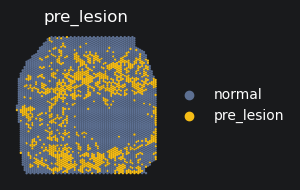

In [8]:
myphescape_ad.pheplot(S2)

### Tutorial 2: Hepatocellular carcinoma dataset
Here, we reapplied PheScape to tumor slices of hepatocellular carcinoma (HCC) to demonstrate its capacity in predicting cellular spatial distribution and elucidating the association between spatial spots and survival outcomes.<br>
The liver cancer spatial data are publicly available at http://lifeome.net/supp/livercancer-st/data.htm. <br>
The single-cell RNA-seq data for hepatocellular carcinoma are available from GEO under accession code GSE149614.<br>
 The bulk RNA-seq data are available from The Cancer Genome Atlas (TCGA-LIHC). The independent validation cohort is available from GEO under accession code GSE14520.<br>

1. Import python modules

In [9]:
import scanpy as sc

  2. Read in data

In [10]:
adata1 = sc.read_h5ad('HCC-1T.h5ad')
adata2 = sc.read_h5ad('sc_HCC.h5ad')  # 单细胞count
adata3 = sc.read_h5ad('TCGA-LIHC_bulk.h5ad')  # 阿兹海默bulk
adata1.var_names_make_unique()
adata2.var_names_make_unique()
adata3.var_names_make_unique()

E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:1840: UserWarning: Variable names are not unique. To make them unique, call `.var_names_make_unique`.
  utils.warn_names_duplicates("var")


  3. Load PheScape model

In [11]:
from model import phescape
myphescape_hcc = phescape(data1=adata1,
                      data2=adata2,
                      data3=adata3,
                      sample='hcc1_t',
)

myphescape_hcc.model_init()

Starting initializing the model...
Initialization completed


  4. Load data

In [12]:
adata1_new0, adata2_new, adata1_new1, adata3_new = myphescape_hcc.load_data()

Starting loading data...


E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


Data loaded


  5. Calculate the coefficient of cell type deconvolution

In [13]:
S1 = myphescape_hcc.cal_corr1(adata1_new0, adata2_new)

Calculate mapping from scRNA to ST


100%|██████████| 1000/1000 [30:45<00:00,  1.85s/it, loss: 1.891e+04]


GPU memory peak value for per slice: 8.18 GB
Run time for per slice: 30.76 分钟


  6. Visualization of cell type deconvolution<br>

Starting plotting...


E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


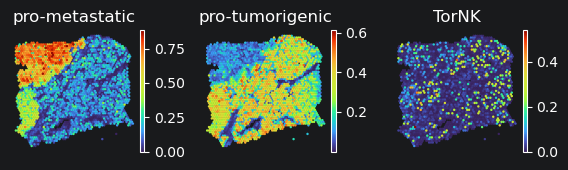

In [14]:
myphescape_hcc.decplot(S1)

  7. Calculate the coefficient of phenotypic mapping

In [15]:
S2 = myphescape_hcc.cal_corr2(adata1_new1, adata3_new)

Calculate mapping from Bulk RNA to ST


100%|██████████| 1000/1000 [00:36<00:00, 27.42it/s, loss: 1.567e+04]

GPU memory peak value for per slice: 0.55 GB
Run time for per slice: 0.61 分钟


  8. Visualization of predicted survival scores<br>

E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Starting plotting...
AnnData object with n_obs × n_vars = 3181 × 33538
    obs: 'in_tissue', 'array_row', 'array_col', 'x_pixel', 'y_pixel', 'seurat_cluster', 'seurat_anno', 'corrected'
    var: 'gene_ids', 'feature_types', 'genome'
    uns: 'seurat_anno_colors', 'spatial'
    obsm: 'spatial'


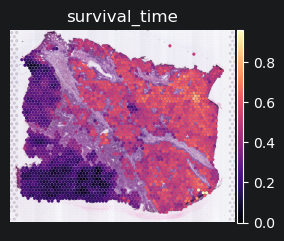

In [16]:
myphescape_hcc.pheplot(S2)

### Tutorial 3: Oral squamous cell carcinoma dataset
Here, we demonstrate the capability of PheScape on an oral squamous cell carcinoma (OSCC) dataset in identifying malignant spots and predicting clinical stage scores.<br>
The spatial transcriptomics data for oral squamous cell carcinoma have been deposited in GEO under accession code GSE208253.<br>
The single-cell RNA-seq data for OSCC are available from GEO under accession code GSE103322.<br>
The bulk RNA-seq data are available from TCGA-HNSC.<br>

1. Import python modules

In [17]:
import scanpy as sc

  2. Read in data

In [18]:
adata1 = sc.read_h5ad('oscc_slice3.h5ad')
adata2 = sc.read_h5ad('sc_hnsc.h5ad')  # 单细胞count
adata3 = sc.read_h5ad('TCGA_HNSC.h5ad')  # 单细胞count

adata1.var_names_make_unique()
adata2.var_names_make_unique()
adata3.var_names_make_unique()

3. Load PheScape model

In [19]:
from model import phescape
myphescape_oscc = phescape(data1=adata1,
                      data2=adata2,
                      data3=adata3,
                      sample='oscc_slice3',
)

myphescape_oscc.model_init()

Starting initializing the model...
Initialization completed


4. Load data

In [20]:
adata1_new0, adata2_new, adata1_new1, adata3_new = myphescape_oscc.load_data()

Starting loading data...


E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


Data loaded


  5. Calculate the coefficient of cell type deconvolution

In [21]:
S1 = myphescape_oscc.cal_corr1(adata1_new0, adata2_new)


Calculate mapping from scRNA to ST


100%|██████████| 1000/1000 [02:02<00:00,  8.14it/s, loss: 1.983e+04]


GPU memory peak value for per slice: 0.80 GB
Run time for per slice: 2.05 分钟


  6. Visualization of cell type deconvolution<br>

Starting plotting...


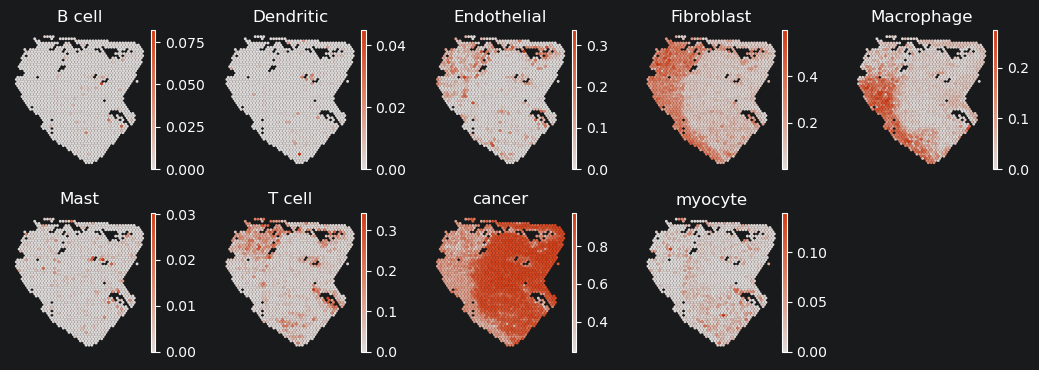

E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


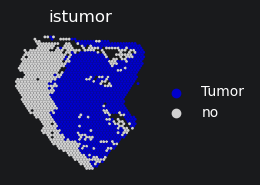

In [22]:
myphescape_oscc.decplot(S1)

  7. Calculate the coefficient of phenotypic mapping

In [23]:
S2 = myphescape_oscc.cal_corr2(adata1_new1, adata3_new)

Calculate mapping from Bulk RNA to ST


100%|██████████| 1000/1000 [00:13<00:00, 72.46it/s, loss: 8.231e+03]

GPU memory peak value for per slice: 0.19 GB
Run time for per slice: 0.23 分钟


  8. Visualization of predicted clinical stage scores<br>

E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:121: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)


Starting plotting...


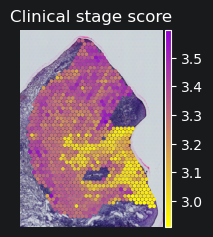

In [24]:
myphescape_oscc.pheplot(S2)

### Tutorial 4: Ovarian cancer dataset
Here, we demonstrate the capability of PheScape on an ovarian cancer (OV) dataset in identifying malignant regions and predicting regional drug sensitivity.<br>
The spatial transcriptomics and single-cell RNA-seq data for ovarian cancer are available from GEO under accession code GSE211956.<br>
Expression and methylation data from A2780 (cisplatin-sensitive) and Round5 A2780 (cisplatin-resistant) cell lines are available from GEO under accession code GSE15372.<br>

1. Import python modules<br>

In [25]:
import scanpy as sc

2. Read in data

In [26]:
adata1 = sc.read_h5ad('s3.h5ad')
adata2 = sc.read_h5ad('sc_ov.h5ad')
adata3 = sc.read_h5ad('cellline_cisplatin.h5ad')
adata1.var_names_make_unique()
adata2.var_names_make_unique()
adata3.var_names_make_unique()

3. Load PheScape model

In [27]:
from model import phescape
myphescape_ov = phescape(data1=adata1,
                      data2=adata2,
                      data3=adata3,
                      sample='ov_s3',
)

myphescape_ov.model_init()

Starting initializing the model...
Initialization completed


4. Load data

In [28]:
adata1_new0, adata2_new, adata1_new1, adata3_new = myphescape_ov.load_data()

Starting loading data...
AnnData object with n_obs × n_vars = 2124 × 33538
    obs: 'array_row', 'array_col', 'x_pixel', 'y_pixel'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 16682 × 4415
    obs: 'Fine-grain annotations', 'Sample'


E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(


AnnData object with n_obs × n_vars = 2124 × 33538
    obs: 'array_row', 'array_col', 'x_pixel', 'y_pixel'
    var: 'gene_ids', 'feature_types'
    obsm: 'spatial'
AnnData object with n_obs × n_vars = 10 × 21755
    obs: 'cisplatin_reaction'


E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\anndata\_core\anndata.py:1763: FutureWarning: The AnnData.concatenate method is deprecated in favour of the anndata.concat function. Please use anndata.concat instead.

See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  warnings.warn(
E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\scanpy\preprocessing\_highly_variable_genes.py:62: UserWarning: `flavor='seurat_v3'` expects raw count data, but non-integers were found.
  warnings.warn(


Data loaded


  5. Calculate the coefficient of cell type deconvolution

In [29]:
S1 = myphescape_ov.cal_corr1(adata1_new0, adata2_new)

Calculate mapping from scRNA to ST


100%|██████████| 1000/1000 [03:40<00:00,  4.53it/s, loss: 2.178e+04]

GPU memory peak value for per slice: 1.51 GB
Run time for per slice: 3.68 分钟


  6. Visualization of cell type deconvolution<br>

Starting plotting...


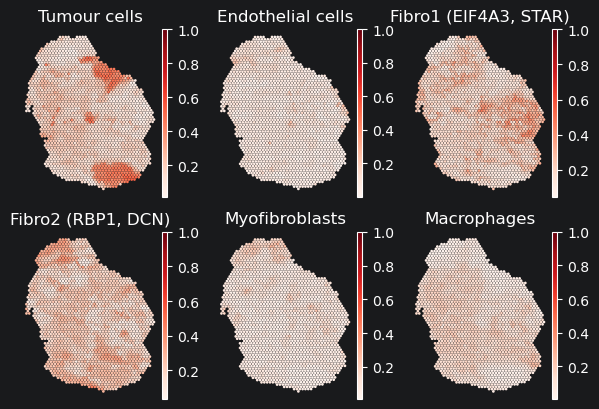

E:\environment2023\Anaconda3\envs\zhenghe3\lib\site-packages\scanpy\plotting\_tools\scatterplots.py:392: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


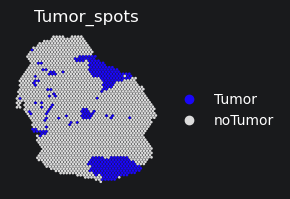

In [30]:
myphescape_ov.decplot(S1)

  7. Calculate the coefficient of phenotypic mapping

In [31]:
S2 = myphescape_ov.cal_corr2(adata1_new1, adata3_new)

Calculate mapping from Bulk RNA to ST


100%|██████████| 5000/5000 [01:38<00:00, 50.72it/s, loss: 1.117e+04]

GPU memory peak value for per slice: 0.33 GB
Run time for per slice: 1.64 分钟


  8. Visualization of predicted cisplatin sensitivity scores<br>

Starting plotting...


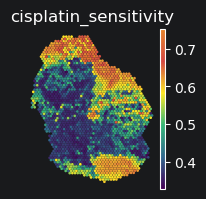

In [32]:
myphescape_ov.pheplot(S2)